# Battery Impact Analysis - Kalix, Sweden

This notebook analyzes the impact of adding a **10 kWh battery** to two different solar configurations at coordinates **65.916940, 22.649684** (Kalix):
1. **Scenario 1**: One 10 kW SE array + 10 kWh Battery.
2. **Scenario 2**: 10 kW SE + 10 kW NW arrays + 10 kWh Battery.

We specifically examine how the **Arbitrage Logic** uses spot prices to charge from the grid during winter (Dec 30).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import os

from solar.config import SimulationConfig, SolarStringConfig, BatteryConfig
from solar.simulation import run_simulation

# Setting constants
PROCESSED_DIR = "../data/processed"
YEAR = "2025"

# Location: Kalix
LAT = 65.916940
LON = 22.649684

## 1. Scenario Setup

Both scenarios include a **10 kWh / 5 kW battery system** configured for arbitrage and self-consumption.

In [2]:
battery_cfg = BatteryConfig(
    capacity_kwh=20.0, 
    max_power_kw=5.0, 
    round_trip_efficiency=0.95, 
    fcr_allocation_pct=0.0
)

# Scenario 1: 10kW SE + Battery
config1 = SimulationConfig(
    latitude=LAT, longitude=LON,
    pv_strings=[SolarStringConfig(capacity_kw=10.0, tilt=35, azimuth=135)],
    battery=battery_cfg, return_timeseries=True
)

# Scenario 2: 20kW SE+NW + Battery
config2 = SimulationConfig(
    latitude=LAT, longitude=LON,
    pv_strings=[
        SolarStringConfig(capacity_kw=10.0, tilt=35, azimuth=135),
        SolarStringConfig(capacity_kw=10.0, tilt=35, azimuth=315)
    ],
    battery=battery_cfg, return_timeseries=True
)

## 2. Run Simulations

In [3]:
metrics1, ts1 = run_simulation(config1, PROCESSED_DIR, YEAR)
metrics2, ts2 = run_simulation(config2, PROCESSED_DIR, YEAR)

print(f"Scenario 1 Annual Battery Throughput: {ts1['battery_charged_kwh'].sum():,.0f} kWh")
print(f"Scenario 2 Annual Battery Throughput: {ts2['battery_charged_kwh'].sum():,.0f} kWh")

Scenario 1 Annual Battery Throughput: 5,342 kWh
Scenario 2 Annual Battery Throughput: 6,133 kWh


## 3. Comparative Visualization

We use a unified plotting helper to visualize both power flows (left axis) and electricity prices (right axis).

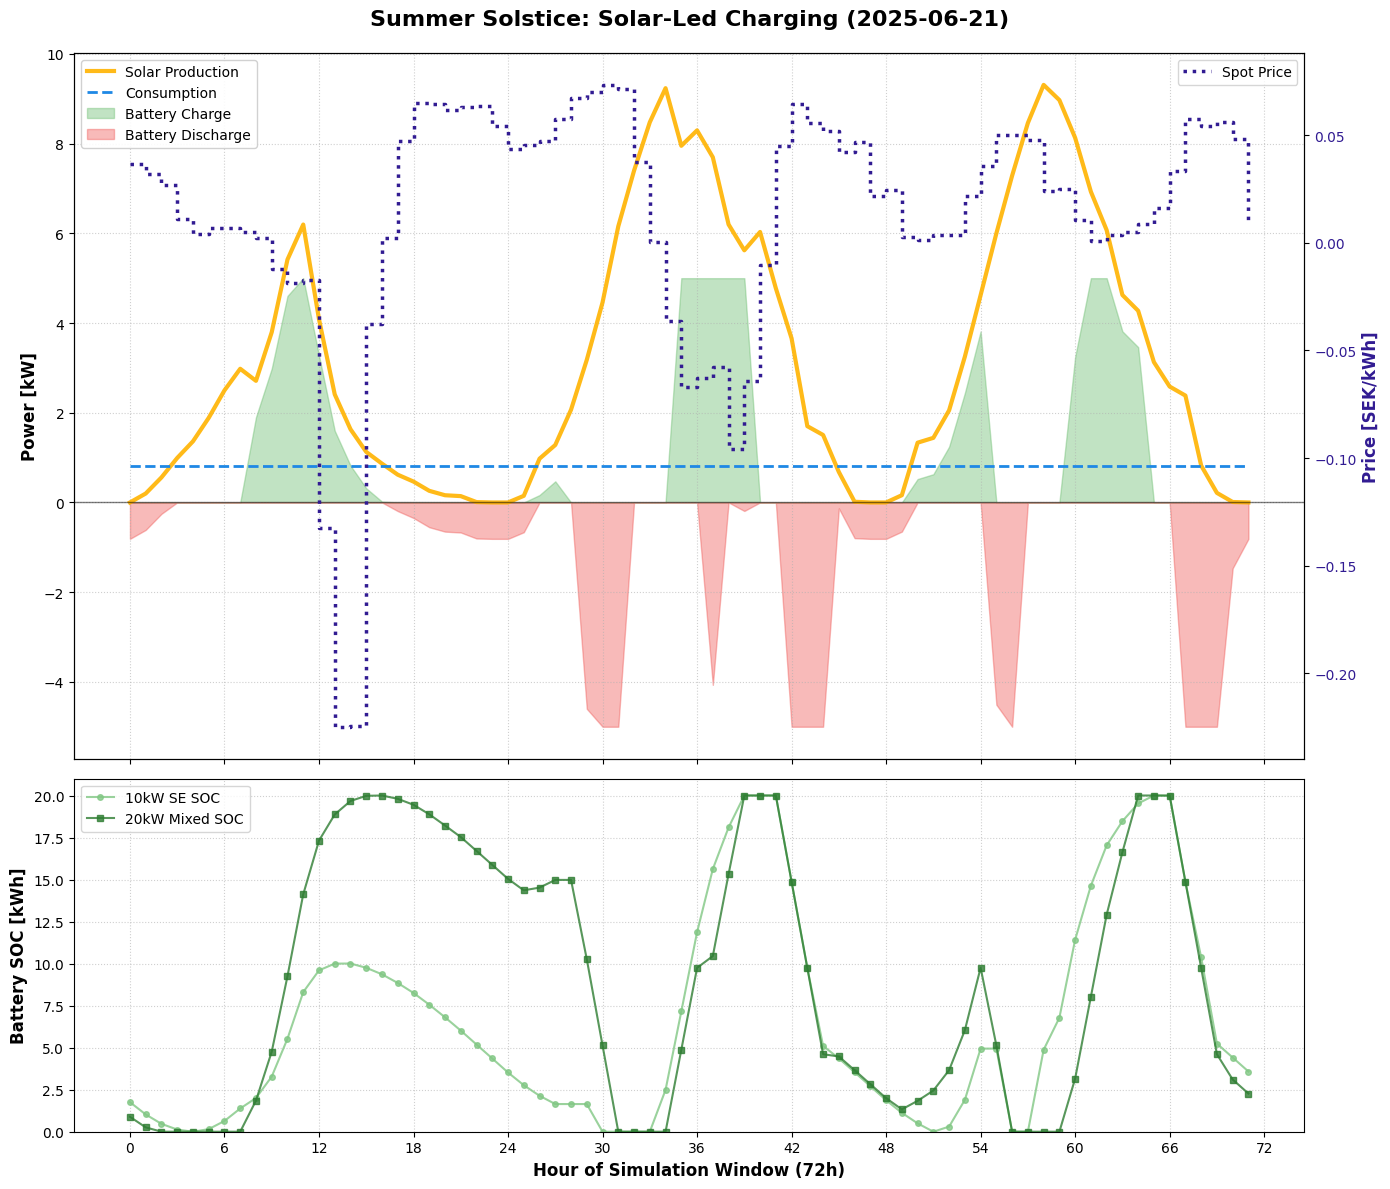

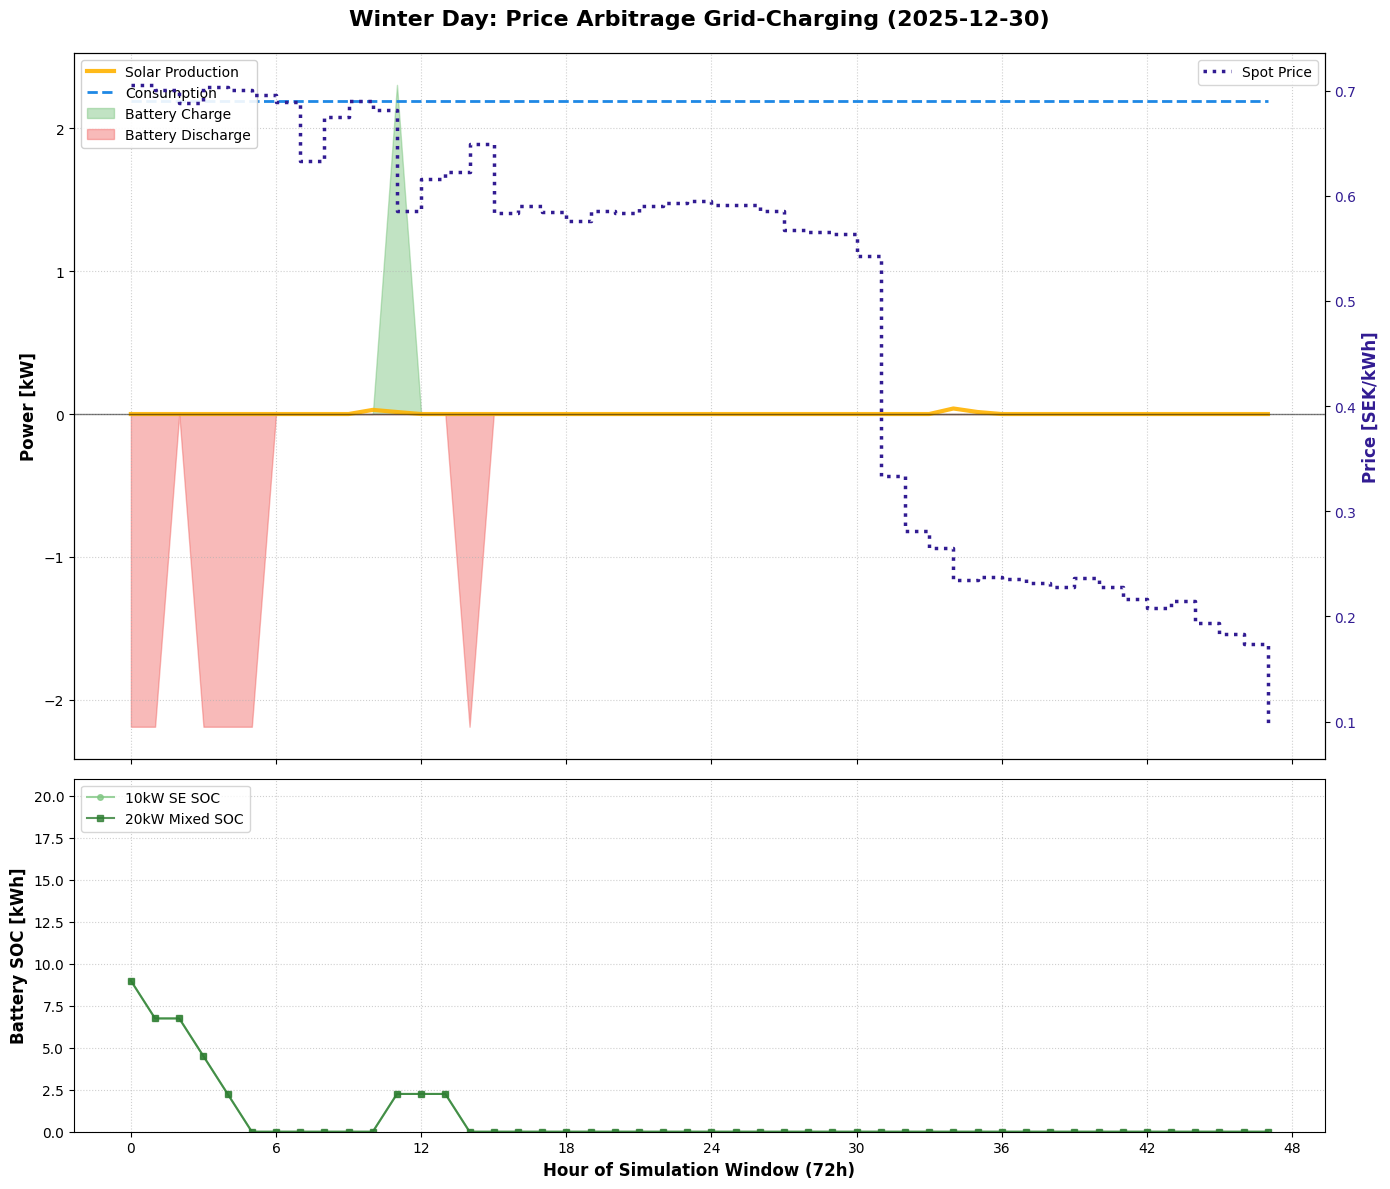

In [4]:
def plot_system_profile(ts_dfs, labels, date_str, title):
    """
    Premium plotting helper for power flows and spot prices.
    """
    time_index = pd.date_range(f"{YEAR}-01-01", periods=8760, freq="h", tz="Europe/Stockholm")
    start_date = pd.to_datetime(f"{date_str}").date()
    end_date = start_date + pd.Timedelta(days=2)
    mask = (time_index.date >= start_date) & (time_index.date <= end_date)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    
    # Standard Scenario for primary bars (Scenario 2 usually most interesting)
    df = ts_dfs[1][mask]
    hrs = range(len(df))
    
    # 1. Power flows on Left Axis
    ax1.plot(hrs, df['p_solar'], label="Solar Production", color='#FFB300', linewidth=3, alpha=0.9)
    ax1.plot(hrs, df['consumption'], label="Consumption", color='#1E88E5', linestyle='--', linewidth=2)
    
    ax1.fill_between(hrs, df['battery_charged_kwh'], label="Battery Charge", color='#66BB6A', alpha=0.4)
    ax1.fill_between(hrs, -df['battery_discharged_kwh'], label="Battery Discharge", color='#EF5350', alpha=0.4)
    
    ax1.set_title(f"{title} ({date_str})", fontsize=16, fontweight='bold', pad=20)
    ax1.set_ylabel("Power [kW]", fontsize=12, fontweight='bold')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.axhline(0, color='black', linewidth=1, alpha=0.5)
    ax1.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

    # 2. Spot Price on Right Axis
    ax1_price = ax1.twinx()
    ax1_price.step(hrs, df['spot_prices'], color='#311B92', linestyle=':', linewidth=2.5, label="Spot Price", where='post')
    ax1_price.set_ylabel("Price [SEK/kWh]", color='#311B92', fontsize=12, fontweight='bold')
    ax1_price.tick_params(axis='y', labelcolor='#311B92')
    ax1_price.legend(loc='upper right')

    # 3. SOC Comparison on Bottom
    colors = ['#81C784', '#2E7D32']
    for i, (tdf, lbl) in enumerate(zip(ts_dfs, labels)):
        ax2.plot(hrs, tdf[mask]['battery_soc_kwh'], label=f"{lbl} SOC", color=colors[i], marker='o' if i==0 else 's', markersize=4, alpha=0.8)
        
    ax2.set_ylabel("Battery SOC [kWh]", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Hour of Simulation Window (72h)", fontsize=12, fontweight='bold')
    ax2.set_ylim(0, battery_cfg.capacity_kwh + 1)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='upper left')
    
    plt.xticks(range(0, len(df)+1, 6))
    plt.tight_layout()
    plt.show()

# Execute Visualizations
plot_system_profile([ts1, ts2], ["10kW SE", "20kW Mixed"], "2025-06-21", "Summer Solstice: Solar-Led Charging")
plot_system_profile([ts1, ts2], ["10kW SE", "20kW Mixed"], "2025-12-30", "Winter Day: Price Arbitrage Grid-Charging")

### 3b. Grid Interaction Comparison
How much less energy do we buy from the grid with the help of the battery?

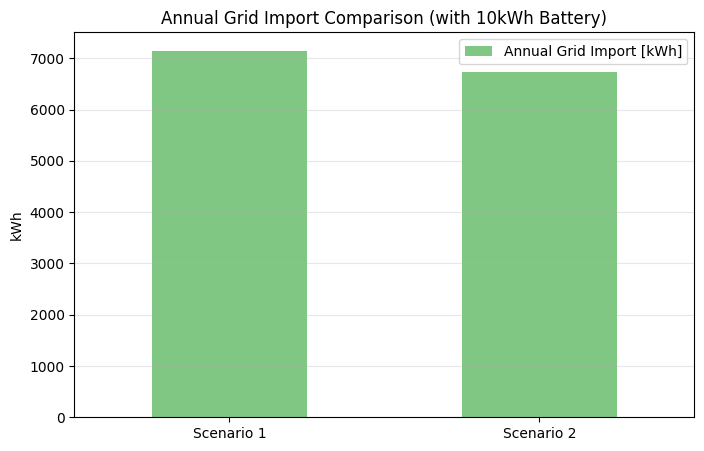

In [5]:
total_buy1 = ts1['grid_buy'].sum()
total_buy2 = ts2['grid_buy'].sum()

grid_stats = pd.DataFrame({
    "Annual Grid Import [kWh]": [total_buy1, total_buy2]
}, index=["Scenario 1", "Scenario 2"])

ax = grid_stats.plot(kind="bar", figsize=(8, 5), rot=0, color=['#81C784', '#2E7D32'])
ax.set_title("Annual Grid Import Comparison (with 10kWh Battery)")
ax.set_ylabel("kWh")
plt.grid(axis='y', alpha=0.3)
plt.show()

### 3d. Solar Curtailment Comparison
Visualizing wasted energy due to grid transmission limits or full batteries.

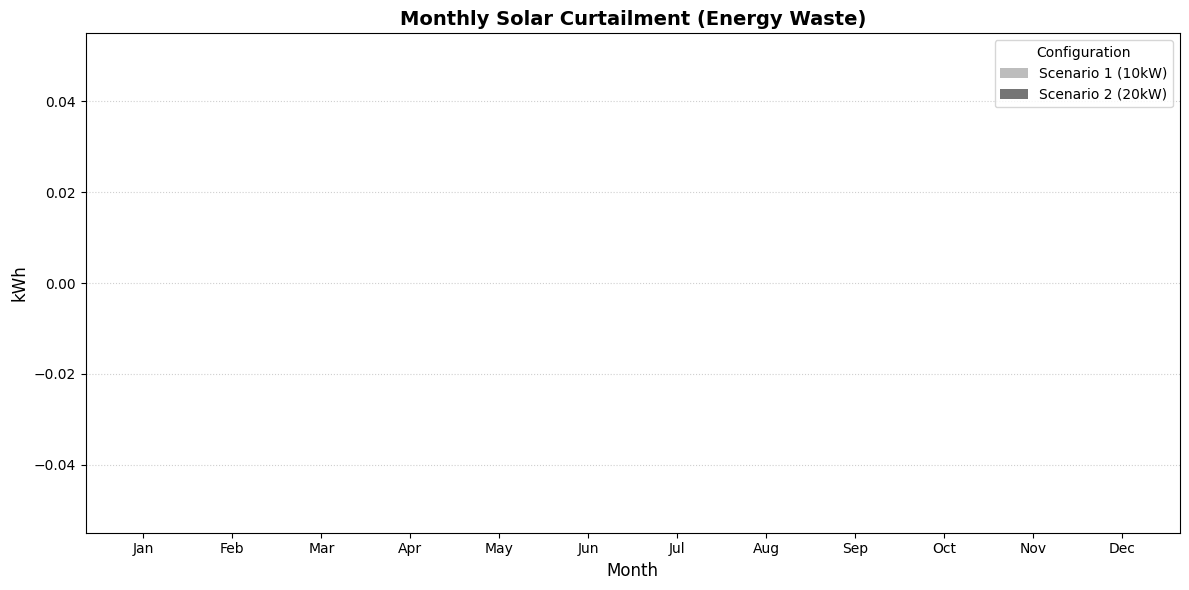

In [6]:
# Resample to Monthly sums
idx = pd.date_range(f"{YEAR}-01-01", periods=8760, freq="h", tz="Europe/Stockholm")
ts1.index = idx
ts2.index = idx

monthly_curt = pd.DataFrame({
    "Scenario 1 (10kW)": ts1['curtailed'].resample('ME').sum(),
    "Scenario 2 (20kW)": ts2['curtailed'].resample('ME').sum()
})
monthly_curt.index = monthly_curt.index.strftime('%b')

ax = monthly_curt.plot(kind="bar", figsize=(12, 6), rot=0, color=['#BDBDBD', '#757575'], width=0.8)
ax.set_title("Monthly Solar Curtailment (Energy Waste)", fontsize=14, fontweight='bold')
ax.set_ylabel("kWh", fontsize=12)
ax.set_xlabel("Month", fontsize=12)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(title="Configuration")

plt.tight_layout()
plt.show()

### 4. Comprehensive Performance Metrics

In [7]:
summary = pd.DataFrame({
    "Metric": [
        "Total Annual Production [kWh]", 
        "Total Battery Throughput [kWh]",
        "Annual Solar Curtailed [kWh]",
        "Total Net Energy Cost [SEK]",
        "Grid Export Credit [SEK]"
    ],
    "Scenario 1 (10kW SE)": [
        ts1['p_solar'].sum(),
        ts1['battery_charged_kwh'].sum(),
        ts1['curtailed'].sum(),
        metrics1['net_electricity_cost_sek'],
        metrics1['total_money_earned_spot_sek']
    ],
    "Scenario 2 (20kW Mixed)": [
        ts2['p_solar'].sum(),
        ts2['battery_charged_kwh'].sum(),
        ts2['curtailed'].sum(),
        metrics2['net_electricity_cost_sek'],
        metrics2['total_money_earned_spot_sek']
    ]
})

summary.style.format(precision=1, thousands=",")

,Metric,Scenario 1 (10kW SE),Scenario 2 (20kW Mixed)
0,Total Annual Production [kWh],"8,920.1","13,404.4"
1,Total Battery Throughput [kWh],"5,342.0","6,132.9"
2,Annual Solar Curtailed [kWh],0.0,0.0
3,Total Net Energy Cost [SEK],"3,461.6","2,348.0"
4,Grid Export Credit [SEK],"1,510.6","2,346.5"


In [8]:
ts2.head()    

,consumption,p_solar,net_load,battery_charged_kwh,battery_discharged_kwh,battery_soc_kwh,grid_buy,grid_sell,unmet_load,curtailed,spot_prices,hourly_spend,hourly_earn_spot,hourly_revenue_fcr
2025-01-01 00:00:00+01:00,2.768817,0.0,2.768817,0.0,0.0,-0.000000,2.768817,0.0,0.0,0.0,0.05588,1.730095,0.0,0.0
2025-01-01 01:00:00+01:00,2.768817,0.0,2.768817,0.0,0.0,-0.000000,2.768817,0.0,0.0,0.0,0.04546,1.694032,0.0,0.0
2025-01-01 02:00:00+01:00,2.768817,0.0,2.768817,5.0,0.0,4.873397,7.768817,0.0,0.0,0.0,0.04374,4.736454,0.0,0.0
2025-01-01 03:00:00+01:00,2.768817,0.0,2.768817,5.0,0.0,9.746794,7.768817,0.0,0.0,0.0,0.03996,4.699746,0.0,0.0
2025-01-01 04:00:00+01:00,2.768817,0.0,2.768817,5.0,0.0,14.620192,7.768817,0.0,0.0,0.0,0.03962,4.696444,0.0,0.0
